## EDA CUSTOMERS Purchase Behavior Analysis 

Purchase behavior

    - Total_Purchases

    - Average_Order_Value

    - Days_Since_Last_Purchase
    
    - Discount_Usage_Rate

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import pandas as pd

df = pd.read_csv('../../../Data/processed/cleaned_customer_data.csv')

In [21]:
purchaseBehaviors_type_data = df[["Total_Purchases", "Average_Order_Value","Days_Since_Last_Purchase", "Discount_Usage_Rate"]]

In [22]:
stats = purchaseBehaviors_type_data.describe().T  # .T = transpose ให้อ่านง่ายขึ้น
stats["skewness"] = purchaseBehaviors_type_data.skew()
stats["kurtosis"] = purchaseBehaviors_type_data.kurt()
stats["outliers"] = 0
stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,outliers
Total_Purchases,50000.0,13.116560,7.005246,0.00,8.00,12.00,17.00,128.700000,2.714766,25.934688,0
Average_Order_Value,50000.0,123.117330,175.569714,26.38,87.05,112.97,144.44,9666.379178,42.363862,1959.931679,0
Days_Since_Last_Purchase,50000.0,29.265300,28.866043,0.00,9.00,21.00,39.00,287.000000,2.090718,6.286718,0
Discount_Usage_Rate,49793.0,41.607486,20.246074,0.24,26.40,40.20,55.30,99.960000,0.334131,-0.428149,0


### 1. Total_Purchases

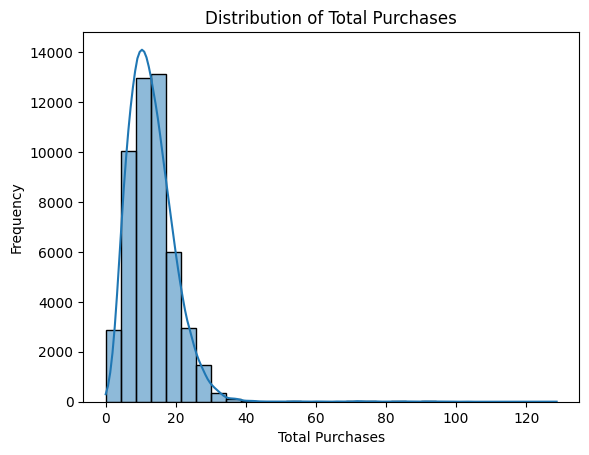

In [23]:
sns.histplot(df["Total_Purchases"], bins=30, kde=True)
plt.title("Distribution of Total Purchases")
plt.xlabel("Total Purchases")
plt.ylabel("Frequency")
plt.show()

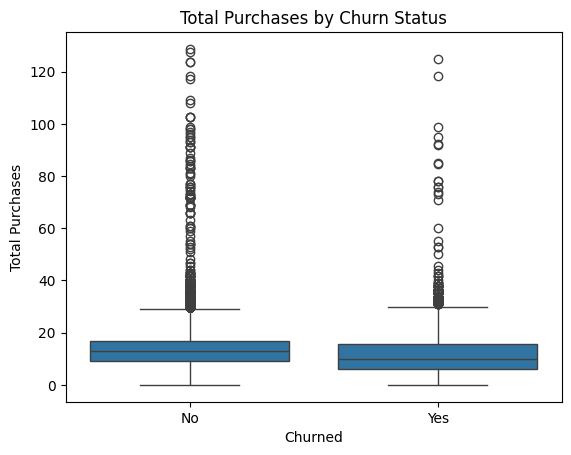

In [24]:
sns.boxplot(data=df, x=df["Churned"].map({1: "Yes", 0: "No"}), y="Total_Purchases")
plt.title("Total Purchases by Churn Status")
plt.xlabel("Churned")
plt.ylabel("Total Purchases")
plt.show()

แบบลองดู Boxplot แบบตัด Outlier ออก

(0.0, 40.0)

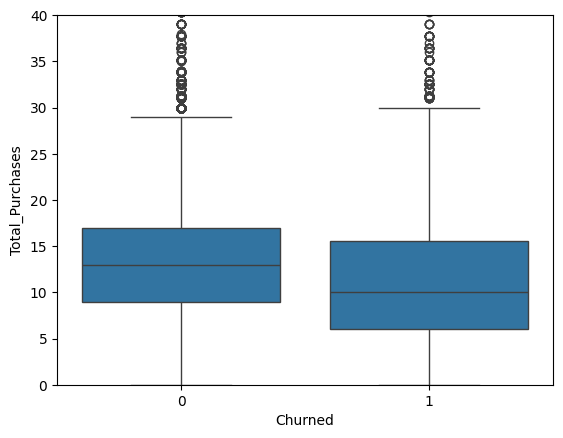

In [25]:
sns.boxplot(x="Churned", y="Total_Purchases", data=df)
plt.ylim(0,40)

<Axes: xlabel='Churned', ylabel='Total_Purchases'>

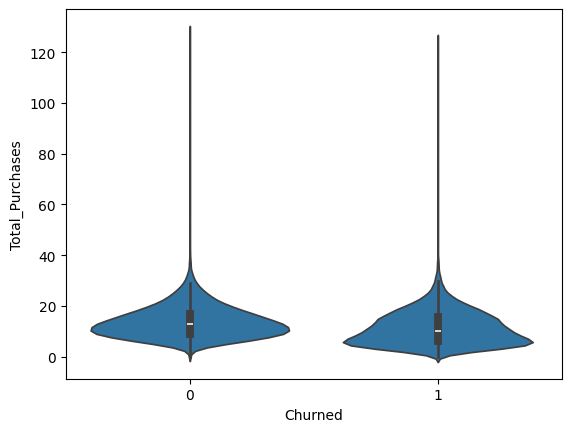

In [26]:
sns.violinplot(x="Churned", y="Total_Purchases", data=df)

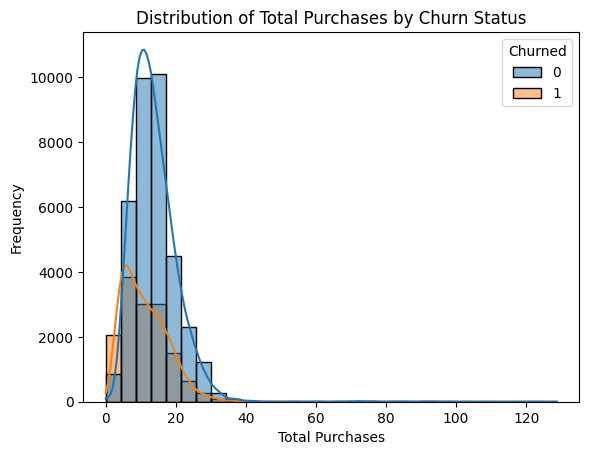

In [27]:
sns.histplot(data=df, x="Total_Purchases", hue="Churned", bins=30, kde=True)
plt.title("Distribution of Total Purchases by Churn Status")
plt.xlabel("Total Purchases")
plt.ylabel("Frequency")
plt.show()

In [31]:
from scipy import stats

churned = df[df["Churned"] == 1]["Total_Purchases"]
not_churned = df[df["Churned"] == 0]["Total_Purchases"]

t_stat, p_value = stats.mannwhitneyu(
    churned,
    not_churned,
    alternative="two-sided"
)

print(f"Mann-Whitney U Test: p-value = {p_value:.6f}")

if p_value < 0.05:
    print("มีความแตกต่างอย่างมีนัยสำคัญระหว่างกลุ่มที่ Churned และ Not Churned ใน Total Purchases")
else:
    print("ไม่มีความแตกต่างอย่างมีนัยสำคัญระหว่างกลุ่มที่ Churned และ Not Churned ใน Total Purchases")

Mann-Whitney U Test: p-value = 0.000000
มีความแตกต่างอย่างมีนัยสำคัญระหว่างกลุ่มที่ Churned และ Not Churned ใน Total Purchases


A Mann-Whitney U test shows a statistically significant difference in total purchases between churned and retained users (p < 0.001). Although the distributions overlap visually, churn rate analysis reveals a clear pattern: customers with fewer purchases exhibit significantly higher churn rates. This suggests that purchase frequency is a meaningful indicator of customer retention.

In [32]:
Q1 = df["Total_Purchases"].quantile(0.25)
Q3 = df["Total_Purchases"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Total_Purchases"] < Q1 - 1.5 * IQR) | 
              (df["Total_Purchases"] > Q3 + 1.5 * IQR)]
print(f"Outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%)")

Outliers: 604 rows (1.21%)


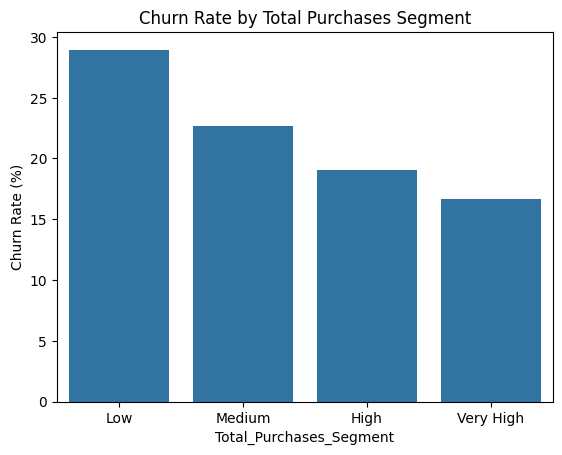

In [36]:
df["Total_Purchases_Segment"] = pd.cut(df["Total_Purchases"], 
                                       bins=4, 
                                       labels=["Low", "Medium", "High", "Very High"])

churn_rate = df.groupby("Total_Purchases_Segment")["Churned"].mean() * 100

sns.barplot(x=churn_rate.index, y=churn_rate.values)
plt.title("Churn Rate by Total Purchases Segment")
plt.ylabel("Churn Rate (%)")
plt.show()

In [37]:
df.groupby("Churned")["Total_Purchases"].median()

Churned
0    13.0
1    10.0
Name: Total_Purchases, dtype: float64